# Sleep Stage Classification using EEG Data

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import LeaveOneGroupOut

import mne
from mne.datasets.sleep_physionet.age import fetch_data

# Two Participants with One Recording for Binary State (Awake or Sleeping)

In [24]:
# Experiment variables

# classification label target
EVENT_ID = {
    "Awake": 1,
    "Sleeping": 2,
}

FREQ_BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

# Step 1: Fetching and Preparing the data

In [25]:
def load_data(participant_id, event_id=EVENT_ID):
  """ 
  
  Will load the EDF with annotation for a given participant and create
  30 seconds epochs.

  Parameters -->
  participant_id:
    The subjects to use. Can be in the range of 0-82 (inclusive), but the
    following subjects are not available: 39, 68, 69, 78 and 79.

  Return --> 
  raw_edf: Contains the edf with the annotations
  events: Contains the 30 seconds events
  epochs: the 30 seconds epoch

  Limitation -->
    Will only get 1 recording session
    Will only work for 1 subject at a time
    
  """

  ANNOTATION_EVENT_ID = {
    "Sleep stage W": 1,
      
    "Sleep stage 1": 2,
    "Sleep stage 2": 2,
    "Sleep stage 3": 2,
    "Sleep stage 4": 2,
    "Sleep stage R": 2,
  }

  # Loading two file paths, one for the signal and one for the annotations
  [participant_file] = fetch_data(subjects=[participant_id], recording=[1])

  # Reading the signal file with information on each signal
  raw_edf = mne.io.read_raw_edf(
    participant_file[0],
    stim_channel="Event marker",
    infer_types=True,
    preload=True,
    verbose="error"
  )

  # Reading the annotation file
  annotation_edf = mne.read_annotations(participant_file[1])

  # keeping last 4h wake events before sleep and first 4h wake events after
  # sleeping and redefining annotations on raw data
  annotation_edf.crop(annotation_edf[1]["onset"] - 30 * 240, annotation_edf[-2]["onset"] + 30 * 240)

  # Attaching the annotation file to the raw edf loaded
  raw_edf.set_annotations(annotation_edf, emit_warning=False)

  # Chunk the data into 30 seconds epochs
  events, _ = mne.events_from_annotations(
      raw_edf, event_id=ANNOTATION_EVENT_ID, chunk_duration=30.0
  )


  # Creating the epochs so that we can use it for classification
  tmax = 30.0 - 1.0 / raw_edf.info["sfreq"]  # defining tmax

  epochs = mne.Epochs(
      raw=raw_edf,
      events=events,
      event_id=event_id,
      tmin=0.0,
      tmax=tmax,
      baseline=None,
      preload=True,
  )

  return raw_edf, events, epochs

# The training participant will be the one with ID 0
raw_train, events_train, epochs_train = load_data(participant_id=0)
# The test participant will be the one with ID 1
raw_test, events_test, epochs_test = load_data(participant_id=1)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
1201 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1201 events and 3000 original time points ...
0 bad epochs dropped
Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
1463 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1463 events and 3000 original time points ...
0 bad epochs dropped


In [26]:
print("Training data EDF loaded and structured.")
raw_train

Training data EDF loaded and structured.


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [27]:
print("Training data epochs loaded and structured.")
epochs_train

Training data epochs loaded and structured.


<Epochs | 1201 events (all good), 0 – 29.99 s (baseline off), ~192.4 MiB, data loaded,
 'Awake': 548
 'Sleeping': 653>

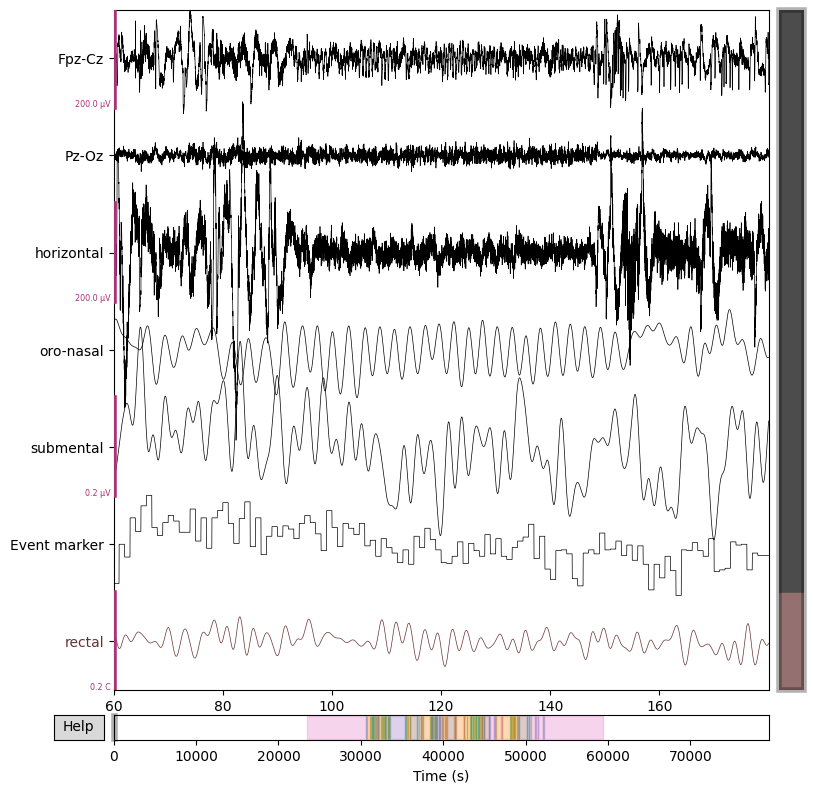

Plot showing the signals from the participant 1
Fpz-Cz and Pz-Oz Channels for brain signals


In [28]:
# Ploting the data
raw_train.plot(
    start=60,
    duration=120,
    scalings=dict(eeg=1e-4, resp=1e3, eog=1e-4, emg=1e-7, misc=1e-1)
)
print("Plot showing the signals from the participant 1")
print("Fpz-Cz and Pz-Oz Channels for brain signals")

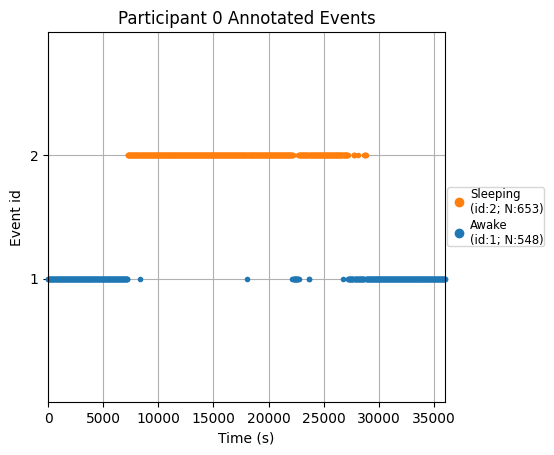

In [29]:
# plotting events across time
fig = mne.viz.plot_events(
    events_train,
    event_id=EVENT_ID,
    sfreq=raw_train.info["sfreq"],
    first_samp=events_train[0, 0],
    show=False,
)
ax = fig.gca()

ax.set_title("Participant 0 Annotated Events")

# keeping the color-code for further plotting
stage_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plt.show()

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


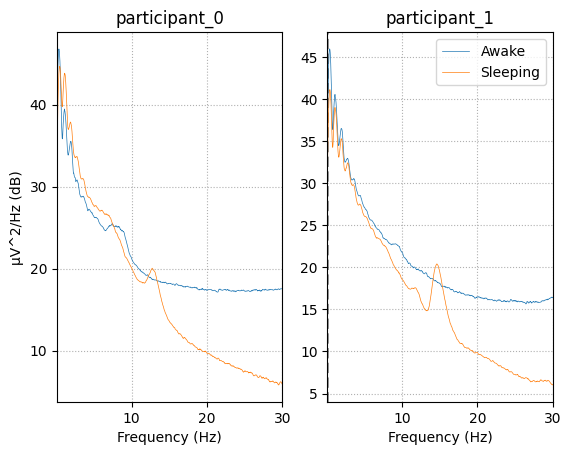

In [30]:
# visualizing participant 0 vs participant 1 PSD by sleep stage
fig, (ax1, ax2) = plt.subplots(ncols=2)

# iterating over the subjects
stages = sorted(EVENT_ID.keys())

for ax, title, epochs in zip([ax1, ax2], ["participant_0", "participant_1"], [epochs_train, epochs_test]):
  for stage, color in zip(stages, stage_colors):
    spectrum = epochs[stage].compute_psd(fmin=0.1, fmax=30.0)
    spectrum.plot(
        ci=None,
        color=color,
        axes=ax,
        show=False,
        average=True,
        amplitude=False,
        spatial_colors=False,
        picks="data",
        exclude="bads",
    )
  ax.set(title=title, xlabel="Frequency (Hz)")
ax1.set(ylabel="µV^2/Hz (dB)")
ax2.legend(ax2.lines[2::3], stages)
plt.show()

## Conclusions:
- ### Participant_0 and participant_1 show nearly identical state-dependent spectral changes.
- ### High-frequency attenuation during sleep (≈15–30 Hz)
- ### Relative enhancement in the 12–15 Hz range during sleep
- ### Low-frequency dominance in both states (<8 Hz)

# Step 2: Feature Calculation

In [31]:
def eeg_power_band(epochs, freq_bands=FREQ_BANDS):
  # Calculating relative spectral analysis on the EEG sensors for each epochs

  # Calculating the spectrogram
  spectrum = epochs.compute_psd(picks="eeg", fmin=0.5, fmax=30.0)
  psds, freqs = spectrum.get_data(return_freqs=True)

  # Normalization
  psds /= np.sum(psds, axis=-1, keepdims=True)

  # shape of PSDS: (epoch, number of channels (we have two), frequency_bins)
  # we'll slice and average to get the delta to theta bands (5 feature per channel)
  # therefore we should finish with (epoch, number of channels * number of bands)

  X = []
  # For each frequency band getting the mean value and adding it to the list X
  for fmin, fmax in freq_bands.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
    X.append(psds_band.reshape(len(psds), -1))

  # returning a numpy array, by reshuffling the list from a (5,841,2) to a (841,10)
  return np.concatenate(X, axis=1)

# Step 3: Classification

In [32]:
# Defining beforehand what is random here for each of the stage given the data we have.
# for the training participant
stages = sorted(EVENT_ID.keys())
random_guess_train = {}
for stage in stages:
  random_guess_train[stage] = len(epochs_train[stage]) / len(epochs_train)

print("Random guess for the training participant: ")
random_guess_train

Random guess for the training participant: 


{'Awake': 0.4562864279766861, 'Sleeping': 0.5437135720233139}

In [33]:
# for the testing participant
random_guess_test = {}
for stage in stages:
  random_guess_test[stage] = len(epochs_test[stage]) / len(epochs_test)

print("Random guess for the testing participant: ")
random_guess_test

Random guess for the testing participant: 


{'Awake': 0.3533834586466165, 'Sleeping': 0.6466165413533834}

In [34]:
# Steps are:
# 1. creating the feature vector X using the epochs
# 2. Using the random forest classifier
pipe = make_pipeline(
    FunctionTransformer(eeg_power_band, validate=False),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Training of the classifier using the participant 0 data
y_train = epochs_train.events[:, 2]
pipe.fit(epochs_train, y_train)

# Testing using the participant 1 data
y_pred = pipe.predict(epochs_test)

y_test = epochs_test.events[:, 2]
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy score: {acc}")

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
Accuracy score: 0.8605604921394395


# Step 4: Result Analysis

              precision    recall  f1-score   support

       Awake       0.72      1.00      0.84       517
    Sleeping       1.00      0.78      0.88       946

    accuracy                           0.86      1463
   macro avg       0.86      0.89      0.86      1463
weighted avg       0.90      0.86      0.86      1463

{'Awake': 1, 'Sleeping': 2}


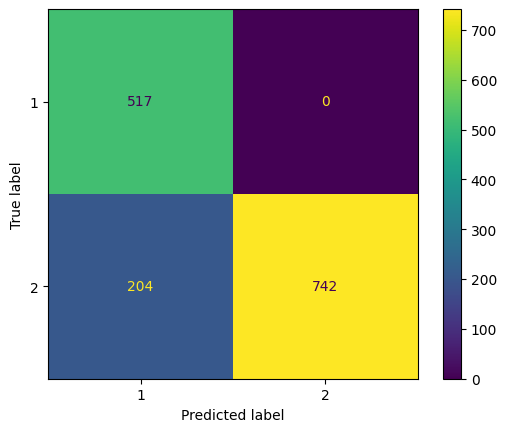

In [35]:
# Creating a confusion matrix and a report on all the metrics
%matplotlib inline
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
print(classification_report(y_test, y_pred, target_names=EVENT_ID.keys()))
print(EVENT_ID)
disp.plot()

--------------------------------------
# Performing EDA of Participant 0, taking all sleep stages.
--------------------------------------

In [36]:
# For this taking all sleep stages into account.
EVENT_ID = {
    "Wake Up": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3/4": 4,
    "REM": 5,
  }

In [37]:
def load_data(participant_id, event_id=EVENT_ID):
  """ 
  
  Will load the EDF with annotation for a given participant and create
  30 seconds epochs.

  Parameters -->
  participant_id:
    The subjects to use. Can be in the range of 0-82 (inclusive), but the
    following subjects are not available: 39, 68, 69, 78 and 79.

  Return --> 
  raw_edf: Contains the edf with the annotations
  events: Contains the 30 seconds events
  epochs: the 30 seconds epoch

  Limitation -->
    Will only get 1 recording session
    Will only work for 1 subject at a time
    
  """

  ANNOTATION_EVENT_ID = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
  }

  # Loading two file paths, one for the signal and one for the annotations
  [participant_file] = fetch_data(subjects=[participant_id], recording=[1])

  # Reading the signal file with information on each signal
  raw_edf = mne.io.read_raw_edf(
    participant_file[0],
    stim_channel="Event marker",
    infer_types=True,
    preload=True,
    verbose="error"
  )

  # Reading the annotation file
  annotation_edf = mne.read_annotations(participant_file[1])

  # keeping last 30-min wake events before sleep and first 30-min wake events after
  # sleep and redefining annotations on raw data
  annotation_edf.crop(annotation_edf[1]["onset"] - 30 * 60, annotation_edf[-2]["onset"] + 30 * 60)

  # Attaching the annotation file to the raw edf loaded
  raw_edf.set_annotations(annotation_edf, emit_warning=False)

  # Chunk the data into 30 seconds epochs
  events, _ = mne.events_from_annotations(
      raw_edf, event_id=ANNOTATION_EVENT_ID, chunk_duration=30.0
  )

  tmax = 30.0 - 1.0 / raw_edf.info["sfreq"] 
    
  # Creating the epochs so that we can use it for classification
  epochs = mne.Epochs(
      raw=raw_edf,
      events=events,
      event_id=event_id,
      tmin=0.0,
      tmax=tmax,
      baseline=None,
  )

  return raw_edf, events, epochs

# The training participant will be the one with ID 0 for now
raw_train, events_train, epochs_train = load_data(participant_id=0)
# The test participant will be the one with ID 1 for now
raw_test, events_test, epochs_test = load_data(participant_id=1)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
841 matching events found
No baseline correction applied
0 projection items activated
Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
1103 matching events found
No baseline correction applied
0 projection items activated


In [38]:
print("Training data EDF loaded and structured.")
raw_train

Training data EDF loaded and structured.


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [39]:
print("Training data events loaded and structured.")
events_train

Training data events loaded and structured.


array([[2883000,       0,       1],
       [2886000,       0,       1],
       [2889000,       0,       1],
       ...,
       [5397000,       0,       1],
       [5400000,       0,       1],
       [5403000,       0,       1]])

In [40]:
print("Training data events loaded and structured.")
events_train

Training data events loaded and structured.


array([[2883000,       0,       1],
       [2886000,       0,       1],
       [2889000,       0,       1],
       ...,
       [5397000,       0,       1],
       [5400000,       0,       1],
       [5403000,       0,       1]])

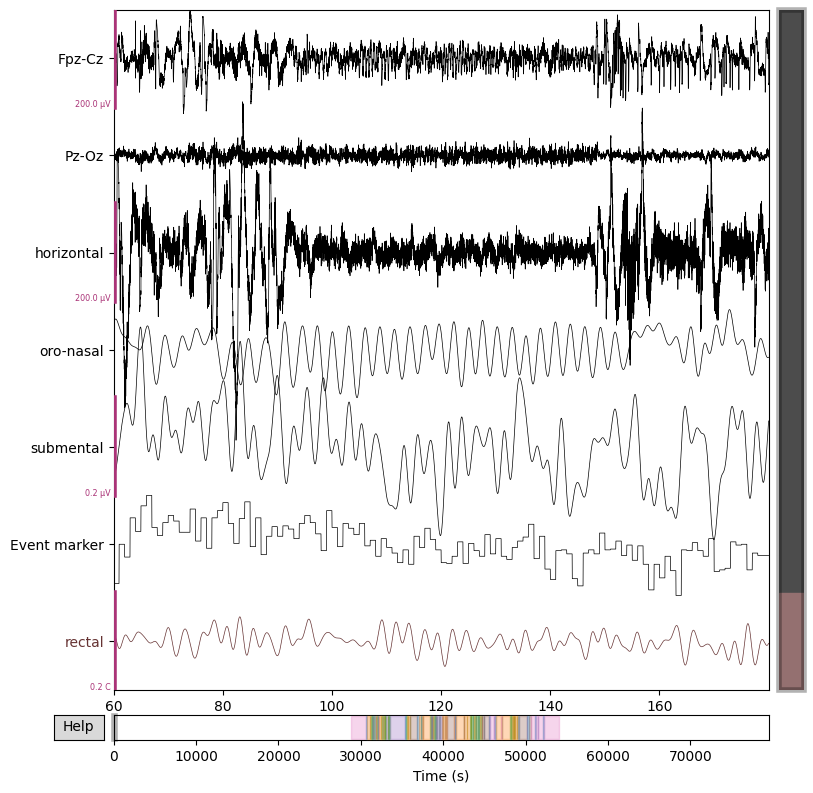

Plot showing the signals from the participant 1


In [41]:
# Plotting the data
raw_train.plot(
    start=60,
    duration=120,
    scalings=dict(eeg=1e-4, resp=1e3, eog=1e-4, emg=1e-7, misc=1e-1)
)
print("Plot showing the signals from the participant 1")

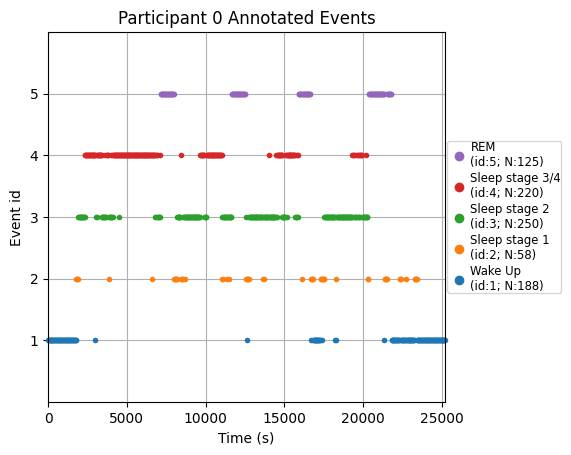

In [42]:
# plotting events across time
fig = mne.viz.plot_events(
    events_train,
    event_id=EVENT_ID,
    sfreq=raw_train.info["sfreq"],
    first_samp=events_train[0, 0],
    show=False,
)
ax = fig.gca()

ax.set_title("Participant 0 Annotated Events")

# keeping the color-code for further plotting
stage_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plt.show()

Using data from preloaded Raw for 125 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Using data from preloaded Raw for 58 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Using data from preloaded Raw for 250 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Using data from preloaded Raw for 220 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Using data fr

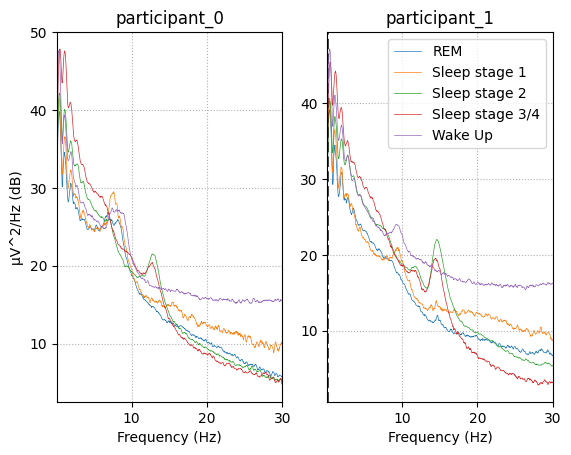

In [43]:
# visualizing participant 0 vs participant 1 PSD by sleep stage
fig, (ax1, ax2) = plt.subplots(ncols=2)

# iterating over the subjects
stages = sorted(EVENT_ID.keys())

for ax, title, epochs in zip([ax1, ax2], ["participant_0", "participant_1"], [epochs_train, epochs_test]):
  for stage, color in zip(stages, stage_colors):
    spectrum = epochs[stage].compute_psd(fmin=0.1, fmax=30.0)
    spectrum.plot(
        ci=None,
        color=color,
        axes=ax,
        show=False,
        average=True,
        amplitude=False,
        spatial_colors=False,
        picks="data",
        exclude="bads",
    )
  ax.set(title=title, xlabel="Frequency (Hz)")
ax1.set(ylabel="µV^2/Hz (dB)")
ax2.legend(ax2.lines[2::3], stages)

## Feature Engineering

In [44]:
def eeg_power_band(epochs, freq_bands=FREQ_BANDS):
  # Calculating relative spectral analysis on the EEG sensors for each epochs

  # Calculating the spectrogram
  spectrum = epochs.compute_psd(picks="eeg", fmin=0.5, fmax=30.0)
  psds, freqs = spectrum.get_data(return_freqs=True)

  # Normalization
  psds /= np.sum(psds, axis=-1, keepdims=True)

  # shape of PSDS:
  # (epoch, number of channels (we have two), frequency_bins)
  # we'll slice and average to get the delta to theta bands (5 feature per channel)
  # therefore we should finish with (epoch, number of channels * number of bands)

  X = []
  # For each frequency band get the mean value and add it to the list X
  for fmin, fmax in freq_bands.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
    X.append(psds_band.reshape(len(psds), -1))

  # returning a numpy array, by reshuffling the list from a (5,841,2) to a (841,10)
  return np.concatenate(X, axis=1)

## Classification

In [45]:
# Our Steps are:
# 1. create the feature vector X using the epochs
# 2. use the random forest classifier
pipe = make_pipeline(
    FunctionTransformer(eeg_power_band, validate=False),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Training of the classifier using the participant 0 data
y_train = epochs_train.events[:, 2]
pipe.fit(epochs_train, y_train)

# Testing using the participant 1 data
y_pred = pipe.predict(epochs_test)

y_test = epochs_test.events[:, 2]
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy score: {acc}")

Using data from preloaded Raw for 841 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Using data from preloaded Raw for 1103 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Accuracy score: 0.6854034451495921


                 precision    recall  f1-score   support

        Wake Up       0.48      0.98      0.64       157
  Sleep stage 1       0.20      0.23      0.22       109
  Sleep stage 2       0.94      0.78      0.85       562
Sleep stage 3/4       0.78      0.96      0.86       105
            REM       0.62      0.23      0.33       170

       accuracy                           0.69      1103
      macro avg       0.60      0.64      0.58      1103
   weighted avg       0.74      0.69      0.68      1103

{'Wake Up': 1, 'Sleep stage 1': 2, 'Sleep stage 2': 3, 'Sleep stage 3/4': 4, 'REM': 5}


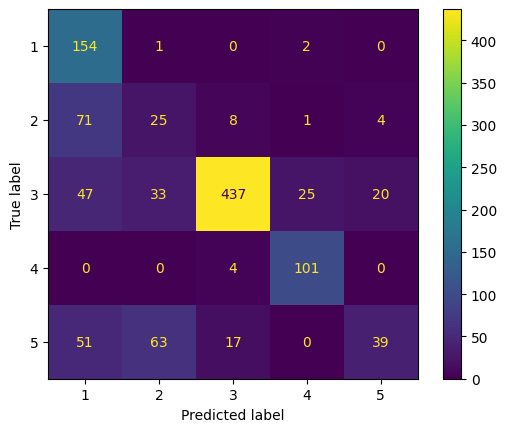

In [46]:
# Create a confusion matrix and a report on all the metrics
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
print(classification_report(y_test, y_pred, target_names=EVENT_ID.keys()))
print(EVENT_ID)